In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("BD_Mo.xlsx")

In [4]:
df.head()

,ID_Empleado,Nombre,Apellido,Estado,Nacimiento,Genero,Departamento,Posicion,Nombre_Jefe,Evaluación,Sueldo
0,1404066949,Adeel,Osturnka,"California, Estados Unidos",1981-11-11,Hombre,Ingeniero Sistema,Ingeneiro II,Alex Sweetwater,9.14,91200
1,1012023185,Adell,Saada,"Texas, Estados Unidos",1991-07-23,Mujer,Ingeniero Sistema,Ingeneiro II,Alex Sweetwater,9.88,88650
2,1106026462,Adil,Sahoo,"California, Estados Unidos",1971-04-25,Hombre,Produccion,Tecnico II,Kelley Spirea,9.38,59400
3,1206038000,Alain,Robinson,"Texas, Estados Unidos",1979-06-30,Hombre,Produccion,Tecnico II,Amy Dunn,9.68,79200
4,1212052023,Alejandro,Bacong,"Texas, Estados Unidos",1993-06-30,Hombre,Tencologia Informacion,Ingeniero I,Peter Monroe,9.35,81500


In [5]:
df.loc[df['Departamento'] == "Executive Office", 'Departamento'] = "Oficina Ejecutiva"

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ID_Empleado   194 non-null    int64         
 1   Nombre        194 non-null    str           
 2   Apellido      194 non-null    str           
 3   Estado        194 non-null    str           
 4   Nacimiento    194 non-null    datetime64[us]
 5   Genero        194 non-null    str           
 6   Departamento  194 non-null    str           
 7   Posicion      194 non-null    str           
 8   Nombre_Jefe   194 non-null    str           
 9   Evaluación    194 non-null    float64       
 10  Sueldo        194 non-null    int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(7)
memory usage: 32.3 KB


In [9]:
df["Nacimiento"] = pd.to_datetime(df["Nacimiento"], errors="coerce")
df["Evaluación"] = pd.to_numeric(df["Evaluación"], errors="coerce")
df["Sueldo"] = pd.to_numeric(df["Sueldo"], errors="coerce")

In [10]:
df[["Evaluación","Sueldo"]].describe()

,Evaluación,Sueldo
count,194.000000,194.000000
mean,7.562474,74721.530928
std,1.378497,28102.547070
min,5.010000,26536.000000
25%,6.492500,52186.500000
50%,7.430000,72905.000000
75%,8.795000,97335.000000
max,9.930000,144000.000000


1. Limpieza y variables derivadas

In [12]:
import pandas as pd
from datetime import datetime

df["Edad"] = (pd.Timestamp("today") - df["Nacimiento"]).dt.days // 365
df["Rango_Edad"] = pd.cut(
    df["Edad"],
    bins=[0, 30, 40, 50, 100],
    labels=["<30", "30-39", "40-49", "50+"]
)

2. Descriptivo básico
Tabla de frecuencias de Genero, Departamento, Posicion, Estado.

Medias y dispersión de Sueldo y Evaluación (global y por grupos).

In [16]:
df["Genero"].value_counts(normalize=True)
df.groupby("Departamento")["Sueldo"].agg(["mean", "std", "min", "max"])
df.groupby("Genero")["Evaluación"].mean()

Genero
Hombre    7.486047
Mujer     7.623333
Name: Evaluación, dtype: float64

In [17]:
import scipy.stats as stats

# 1. Comparar sueldo por género (t-test independiente)
sueldo_h = df[df["Genero"] == "Hombre"]["Sueldo"]
sueldo_m = df[df["Genero"] == "Mujer"]["Sueldo"]

t_sueldo, p_sueldo = stats.ttest_ind(sueldo_h, sueldo_m, equal_var=False)
print("t Sueldo H vs M:", t_sueldo)
print("p Sueldo H vs M:", p_sueldo)

# 2. Comparar evaluación por género (t-test)
eval_h = df[df["Genero"] == "Hombre"]["Evaluación"]
eval_m = df[df["Genero"] == "Mujer"]["Evaluación"]

t_eval, p_eval = stats.ttest_ind(eval_h, eval_m, equal_var=False)
print("t Evaluación H vs M:", t_eval)
print("p Evaluación H vs M:", p_eval)

# 3. ANOVA de sueldo por departamento
grupos_sueldo_depto = [g["Sueldo"].values for _, g in df.groupby("Departamento")]
f_depto, p_depto = stats.f_oneway(*grupos_sueldo_depto)
print("F Sueldo por Departamento:", f_depto)
print("p Sueldo por Departamento:", p_depto)

# 4. Correlación entre sueldo y evaluación
r_se, p_se = stats.pearsonr(df["Sueldo"], df["Evaluación"])
print("r Sueldo-Evaluación:", r_se)
print("p Sueldo-Evaluación:", p_se)

t Sueldo H vs M: 1.9838156266581197
p Sueldo H vs M: 0.048806132091590494
t Evaluación H vs M: -0.6834233476060769
p Evaluación H vs M: 0.4952321548387934
F Sueldo por Departamento: 28.39543580190641
p Sueldo por Departamento: 5.265020477125172e-24
r Sueldo-Evaluación: -0.126092915311051
p Sueldo-Evaluación: 0.07978749136917747


Sueldo por género: la prueba t dio p = 0.0489, así que sí hay una diferencia estadísticamente significativa al 5% entre hombres y mujeres en el sueldo.

Evaluación por género: p = 0.4952, por lo que no hay evidencia de diferencia significativa en la evaluación entre hombres y mujeres.

Sueldo por departamento: el ANOVA dio p = 5.265e-24, así que existen diferencias muy marcadas de sueldo entre departamentos.

Relación sueldo–evaluación: p = 0.0798, por lo que no se observa una correlación lineal significativa al 5%.

En la base 5 se analizaron variables relacionadas con empleados, incluyendo género, departamento, evaluación y sueldo. En el análisis descriptivo se observó una distribución equilibrada por género, con 50% hombres y 50% mujeres, y una evaluación media ligeramente mayor en mujeres.

Al aplicar una prueba t para comparar sueldos entre hombres y mujeres, se obtuvo un valor p menor a 0.05, lo que indica diferencias estadísticamente significativas en el sueldo según el género. En cambio, al comparar la evaluación entre géneros, no se encontraron diferencias significativas.

Por otro lado, el ANOVA aplicado al sueldo por departamento mostró diferencias altamente significativas entre áreas, lo que sugiere que el departamento influye fuertemente en el nivel salarial. Finalmente, la correlación entre sueldo y evaluación no resultó significativa al 5%, por lo que no se puede afirmar una relación lineal clara entre ambas variables.

En conclusión, la base 5 evidencia que el sueldo depende tanto del género como, sobre todo, del departamento, mientras que la evaluación no presenta diferencias importantes por género ni una relación lineal clara con el salario.

3.Frecuencias de Departamento y Posición + barras

Frecuencias por Departamento:
Departamento
Produccion                73
Tencologia Informacion    40
Administrador Office      35
Ventas                    20
Ingeniero Sistema         18
Oficina Ejecutiva          7
Ingeniero Sistema          1
Name: count, dtype: int64

Frecuencias por Posición:
Posicion
Ingeniero I          39
Tecnico II           33
Ingeneiro II         31
Tecnico I            30
Gerente              20
Administrativa I     15
Administracion II    14
Director             12
Name: count, dtype: int64


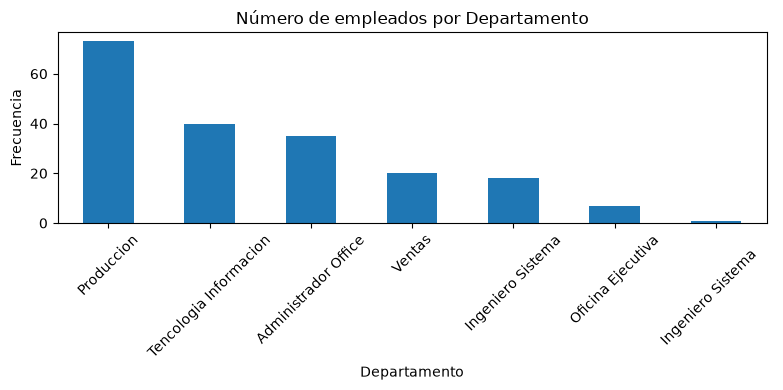

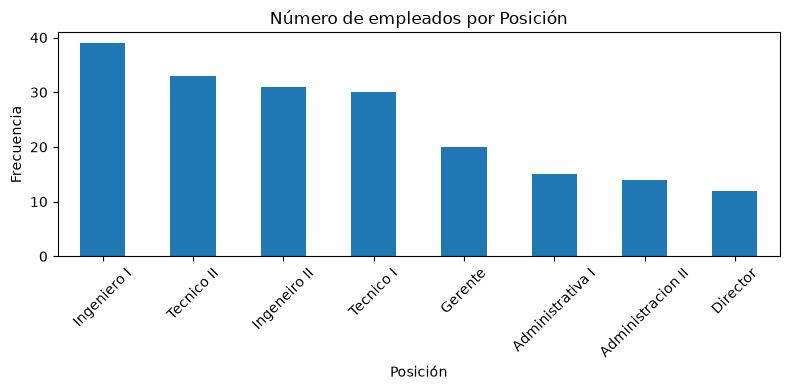

In [18]:
import matplotlib.pyplot as plt

# Frecuencias
freq_depto = df["Departamento"].value_counts()
freq_pos = df["Posicion"].value_counts()

print("Frecuencias por Departamento:")
print(freq_depto)
print("\nFrecuencias por Posición:")
print(freq_pos)

# Barras Departamento
plt.figure(figsize=(8, 4))
freq_depto.plot(kind="bar")
plt.title("Número de empleados por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Barras Posición
plt.figure(figsize=(8, 4))
freq_pos.plot(kind="bar")
plt.title("Número de empleados por Posición")
plt.xlabel("Posición")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El departamento más frecuente es Producción con 73 empleados.

Luego vienen Tecnología Información con 40, Administrador Office con 35 y Ventas con 20.

En posiciones, las más comunes son Ingeniero I (39), Técnico II (33) e Ingeniero II (31).



In [19]:
import pandas as pd
from scipy.stats import chi2_contingency

tabla_gen_dep = pd.crosstab(df["Genero"], df["Departamento"])
print(tabla_gen_dep)

chi2, p_chi, dof_chi, esperados = chi2_contingency(tabla_gen_dep)

print("\nChi-cuadrado Genero vs Departamento:", chi2)
print("p:", p_chi)
print("Grados de libertad:", dof_chi)

Departamento  Administrador Office  Ingeniero Sistema  Ingeniero Sistema       \
Genero                                                                          
Hombre                          15                  6                       1   
Mujer                           20                 12                       0   

Departamento  Oficina Ejecutiva  Produccion  Tencologia Informacion  Ventas  
Genero                                                                       
Hombre                        3          29                      22      10  
Mujer                         4          44                      18      10  

Chi-cuadrado Genero vs Departamento: 4.907601163717761
p: 0.5557175366930147
Grados de libertad: 6


Como p > 0.05, no hay evidencia de que la distribución de género dependa del departamento.

En otras palabras, la proporción de hombres y mujeres parece relativamente homogénea entre áreas.

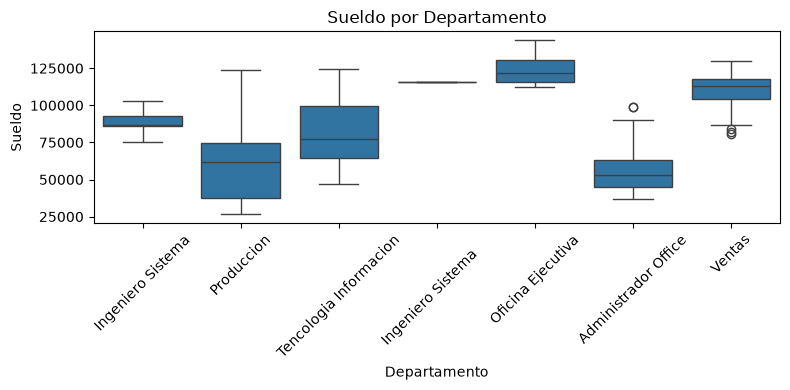

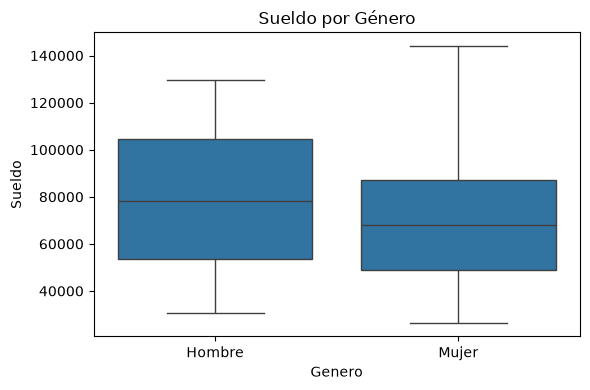

In [20]:
import seaborn as sns

# Boxplot Sueldo por Departamento
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Departamento", y="Sueldo")
plt.title("Sueldo por Departamento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Boxplot Sueldo por Género
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Genero", y="Sueldo")
plt.title("Sueldo por Género")
plt.tight_layout()
plt.show()

Boxplot de sueldo por departamento:
Se observan diferencias claras en los salarios entre áreas:
Oficina Ejecutiva y Ingeniero Sistema aparecen con sueldos más altos.
Administrador Office y Producción muestran sueldos más bajos.
Hay dispersión distinta según el departamento, lo que coincide con el ANOVA altamente significativo.

Boxplot de sueldo por género:
La mediana salarial de hombres aparece un poco por encima de la de mujeres.
La variabilidad salarial también parece amplia en ambos grupos.